## Insider Threat Radar – Behavior Analytics for Employee Risk Prediction

### Random Forest 

#### Import Libraries 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt
import joblib

#### Load Data

In [2]:
data = pd.read_csv("../Dataset/anomaly_output.csv")

feature_cols = [
    'total_emails','total_attachments','avg_email_size',
    'off_hour_emails','weekend_emails',
    'O','C','E','A','N'
]

X = data[feature_cols]
y = data['anomaly_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### Train Random Forest

In [3]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

#### Evaluation

In [4]:
rf_pred = rf.predict(X_test)

#### Confusion Matrix & Classification Report 

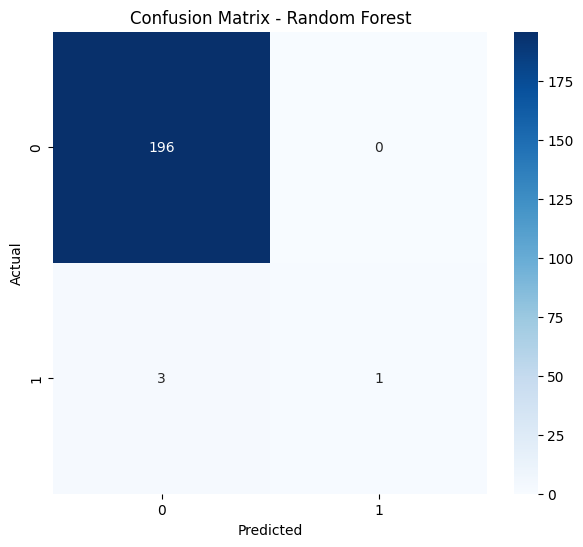


📄 CLASSIFICATION REPORT - RANDOM FOREST

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       196
           1       1.00      0.25      0.40         4

    accuracy                           0.98       200
   macro avg       0.99      0.62      0.70       200
weighted avg       0.99      0.98      0.98       200



In [5]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📄 CLASSIFICATION REPORT - RANDOM FOREST\n")
print(classification_report(y_test, rf_pred))

#### Save Model

In [6]:
joblib.dump(rf, "../Model/random_forest.pkl")
print("Random Forest model saved ✅")

Random Forest model saved ✅
